# 01 - Exploratory Data Analysis

This notebook explores the Kaggle Spotify Tracks dataset before modeling. The objective is to understand the scale, data types, missing values, popularity distribution, and relationships between audio features and song popularity.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
DATA_CLEAN = PROJECT_ROOT / "data" / "processed" / "spotify_tracks_clean.csv"

RANDOM_STATE = 42

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 50)

df = pd.read_csv(DATA_RAW)
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())

Matplotlib is building the font cache; this may take a moment.


Dataset shape: 114,000 rows x 21 columns


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Dataset Structure

Each row represents a Spotify track. The columns include identifiers and descriptive metadata (`track_id`, `artists`, `album_name`, `track_name`, `track_genre`) plus numerical audio attributes such as `danceability`, `energy`, `tempo`, `valence`, and the target variable `popularity`.

In [3]:
display(df.info())
display(df.describe(include="all").T)

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,NaN,NaN,NaN,56999.5,32909.109681,0.0,28499.75,56999.5,85499.25,113999.0
track_id,114000,89741,6S3JlDAGk3uu3NtZbPnuhS,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
artists,113999,31437,The Beatles,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
album_name,113999,46589,Alternative Christmas 2022,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
track_name,113999,73608,Run Rudolph Run,151,NaN,NaN,NaN,NaN,NaN,NaN,NaN
popularity,114000.0,NaN,NaN,NaN,33.238535,22.305078,0.0,17.0,35.0,50.0,100.0
duration_ms,114000.0,NaN,NaN,NaN,228029.153114,107297.712645,0.0,174066.0,212906.0,261506.0,5237295.0
explicit,114000,2,False,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN
danceability,114000.0,NaN,NaN,NaN,0.5668,0.173542,0.0,0.456,0.58,0.695,0.985
energy,114000.0,NaN,NaN,NaN,0.641383,0.251529,0.0,0.472,0.685,0.854,1.0


## Missing Values and Duplicates

Missing values affect cleaning decisions because imputation is only useful when missingness is limited and the column is still analytically valuable. Duplicate tracks can bias model training by allowing the same song to appear more than once.

In [4]:
missing = (
    df.isna().sum()
    .to_frame("missing_count")
    .assign(missing_percent=lambda x: 100 * x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)
display(missing)

print(f"Duplicated rows: {df.duplicated().sum():,}")
print(f"Duplicated track_id values: {df['track_id'].duplicated().sum():,}")

,missing_count,missing_percent
artists,1,0.000877
track_name,1,0.000877
album_name,1,0.000877
Unnamed: 0,0,0.000000
track_id,0,0.000000
popularity,0,0.000000
duration_ms,0,0.000000
explicit,0,0.000000
danceability,0,0.000000
energy,0,0.000000


Duplicated rows: 0
Duplicated track_id values: 24,259


## Central Tendency

Mean and median summarize numerical columns, while mode is useful for categorical attributes such as genre, explicit content, and musical key.

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

central_tendency = pd.DataFrame({
    "mean": df[numeric_cols].mean(numeric_only=True),
    "median": df[numeric_cols].median(numeric_only=True),
    "mode": df[numeric_cols].mode().iloc[0],
})
display(central_tendency)

categorical_modes = df[categorical_cols].mode().iloc[0].to_frame("mode")
display(categorical_modes)

,mean,median,mode
Unnamed: 0,56999.500000,56999.500000,0.0000
popularity,33.238535,35.000000,0.0000
duration_ms,228029.153114,212906.000000,162897.0000
danceability,0.566800,0.580000,0.6470
energy,0.641383,0.685000,0.8760
key,5.309140,5.000000,7.0000
loudness,-8.258960,-7.004000,-5.6620
mode,0.637553,1.000000,1.0000
speechiness,0.084652,0.048900,0.0323
acousticness,0.314910,0.169000,0.9950


,mode
track_id,6S3JlDAGk3uu3NtZbPnuhS
artists,The Beatles
album_name,Alternative Christmas 2022
track_name,Run Rudolph Run
explicit,False
track_genre,acoustic


## Popularity Distribution

Popularity is the regression target. A skewed or uneven distribution means prediction error should be interpreted carefully: predicting exact popularity is harder for sparse high-popularity observations than for common mid-range songs.

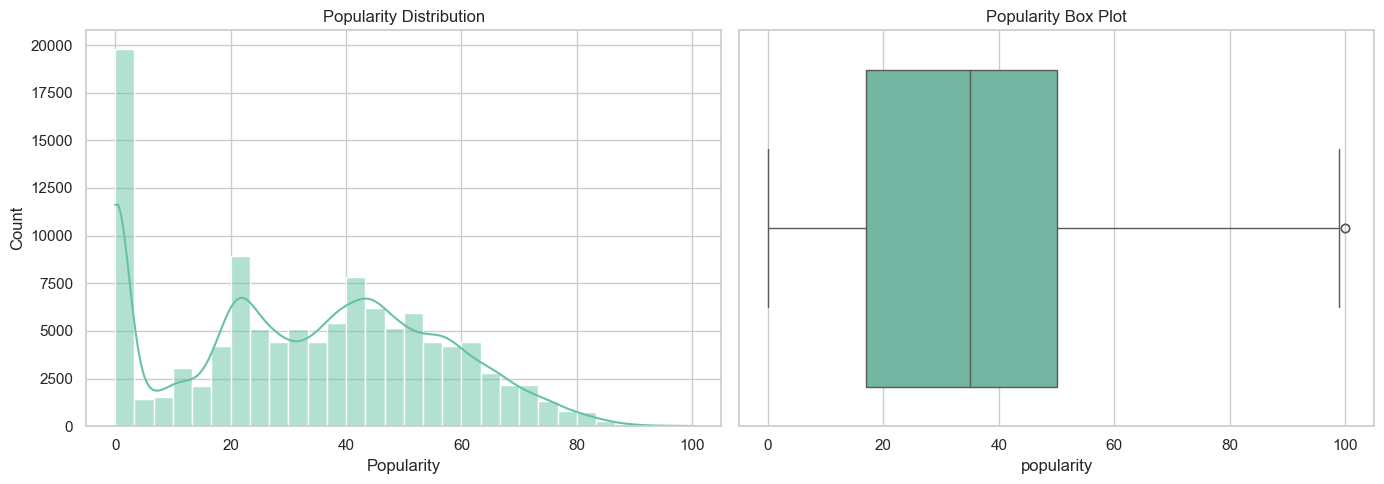

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["popularity"], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Popularity Distribution")
axes[0].set_xlabel("Popularity")

sns.boxplot(x=df["popularity"], ax=axes[1])
axes[1].set_title("Popularity Box Plot")
plt.tight_layout()
plt.show()

print(df["popularity"].describe())

## Audio Feature Distributions

Audio features are mostly bounded between 0 and 1, while `tempo`, `duration_ms`, and `loudness` have different scales. This is why later notebooks standardize features before PCA, clustering, and neural network training.

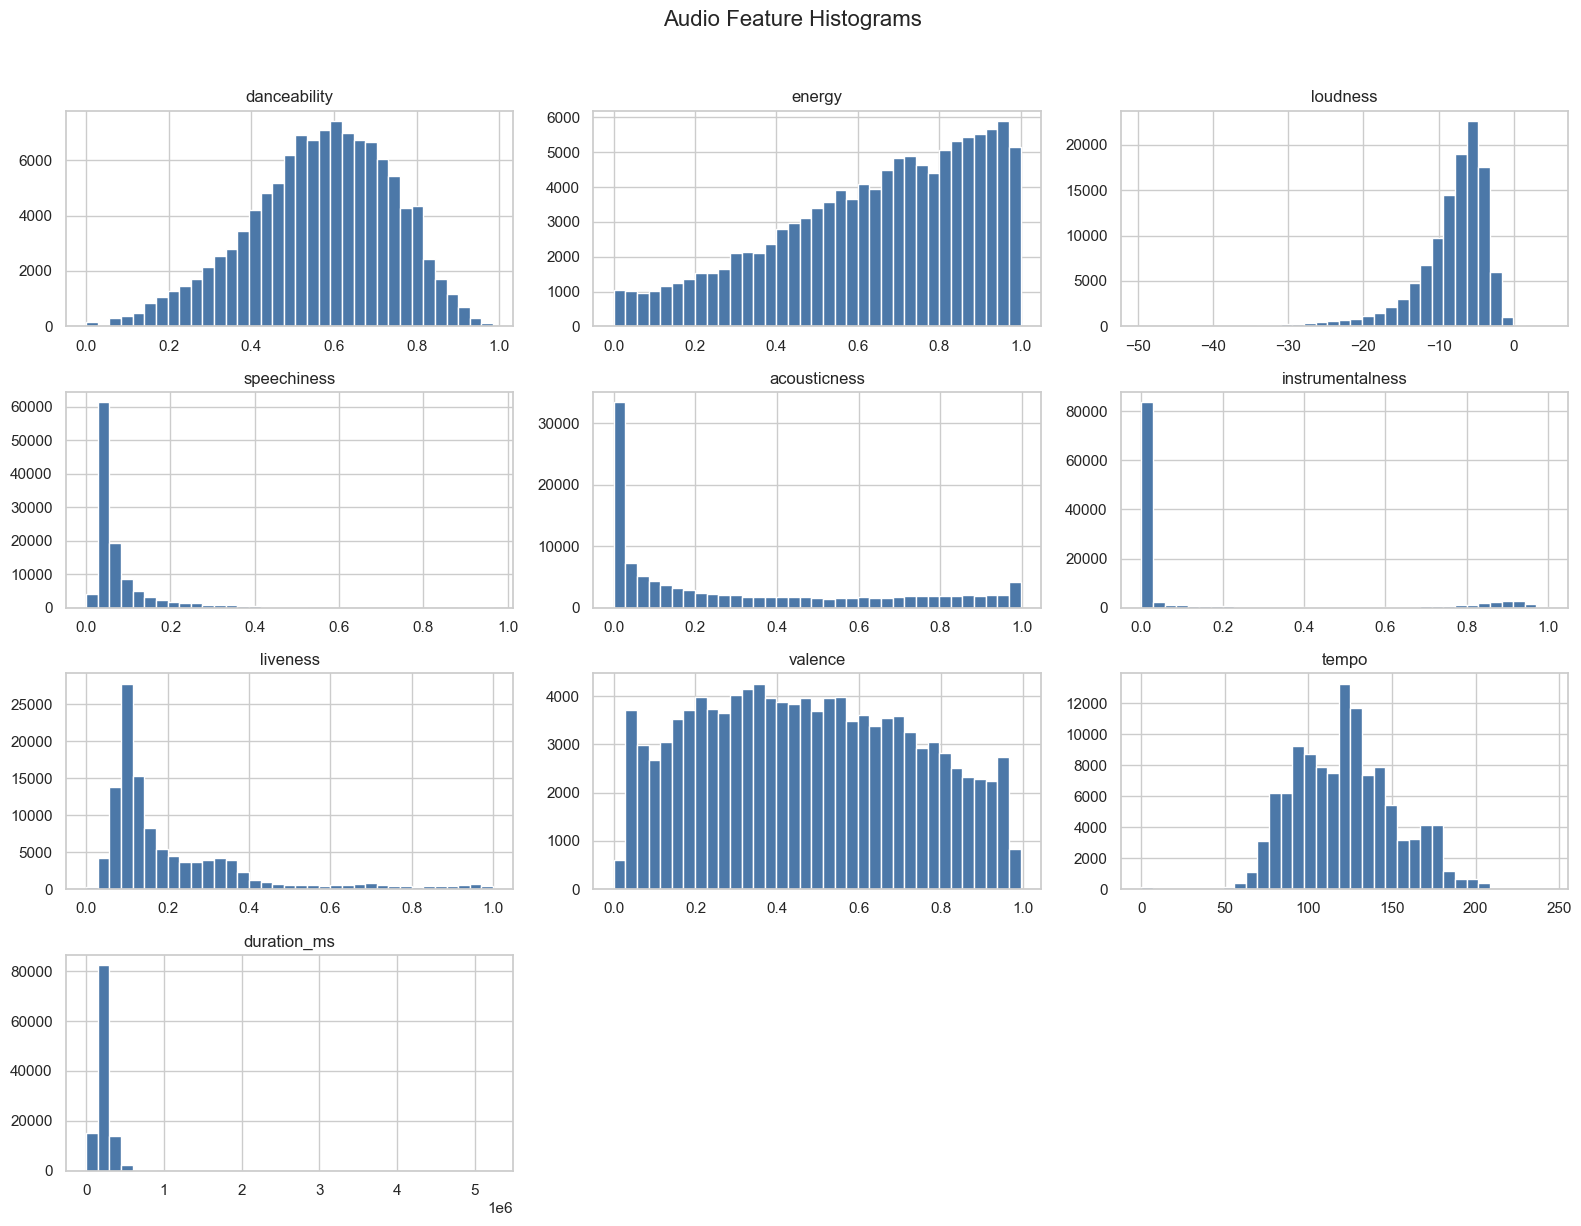

In [7]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "duration_ms"
]

df[audio_features].hist(bins=35, figsize=(16, 12), color="#4C78A8")
plt.suptitle("Audio Feature Histograms", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

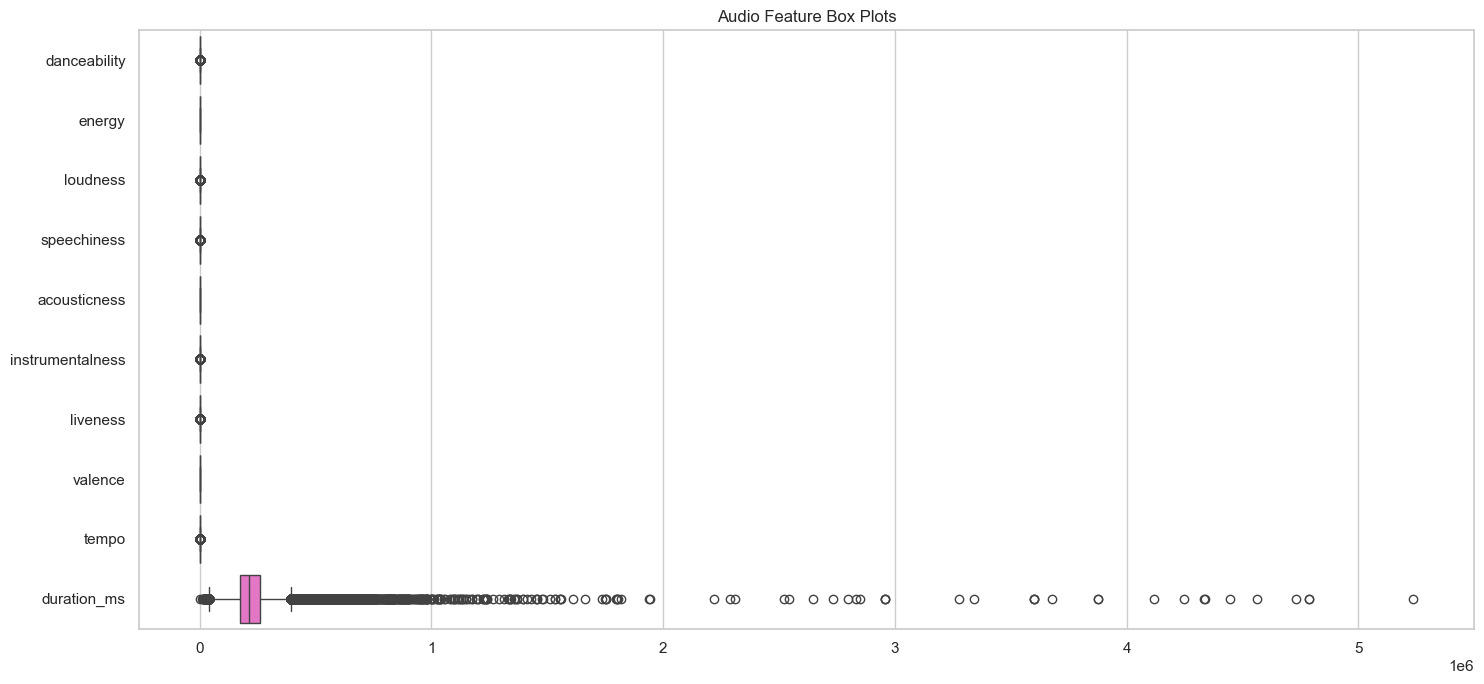

In [8]:
plt.figure(figsize=(15, 7))
sns.boxplot(data=df[audio_features], orient="h")
plt.title("Audio Feature Box Plots")
plt.tight_layout()
plt.show()

## Correlation Analysis

Correlation helps identify linear relationships and potential multicollinearity. It is not proof of causation, but it guides feature interpretation for regression and PCA.

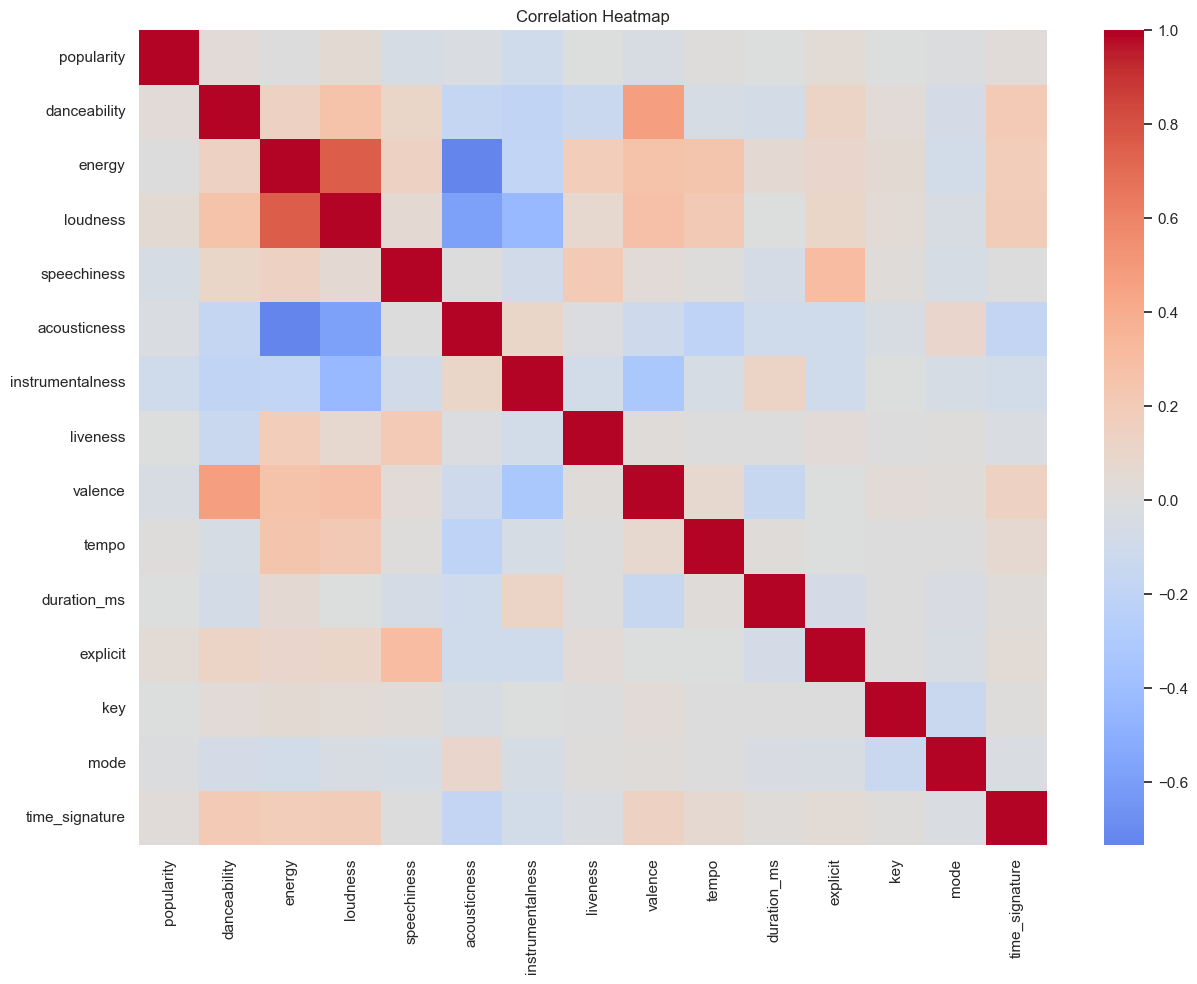

,correlation_with_popularity
instrumentalness,-0.095139
loudness,0.050423
speechiness,-0.044927
explicit,0.044082
valence,-0.040534
danceability,0.035448
time_signature,0.031073
acousticness,-0.025472
mode,-0.013931
tempo,0.013205


In [9]:
corr_cols = ["popularity"] + audio_features + ["explicit", "key", "mode", "time_signature"]
corr = df[corr_cols].copy()
corr["explicit"] = corr["explicit"].astype(int)

plt.figure(figsize=(13, 10))
sns.heatmap(corr.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

popularity_corr = corr.corr(numeric_only=True)["popularity"].drop("popularity").sort_values(key=np.abs, ascending=False)
display(popularity_corr.to_frame("correlation_with_popularity"))

## Scatter Plots Against Popularity

These plots show whether high or low values of audio characteristics are associated with popularity. Wide vertical spread means popularity is influenced by factors outside the dataset too, such as artist reputation, playlist placement, release timing, and marketing.

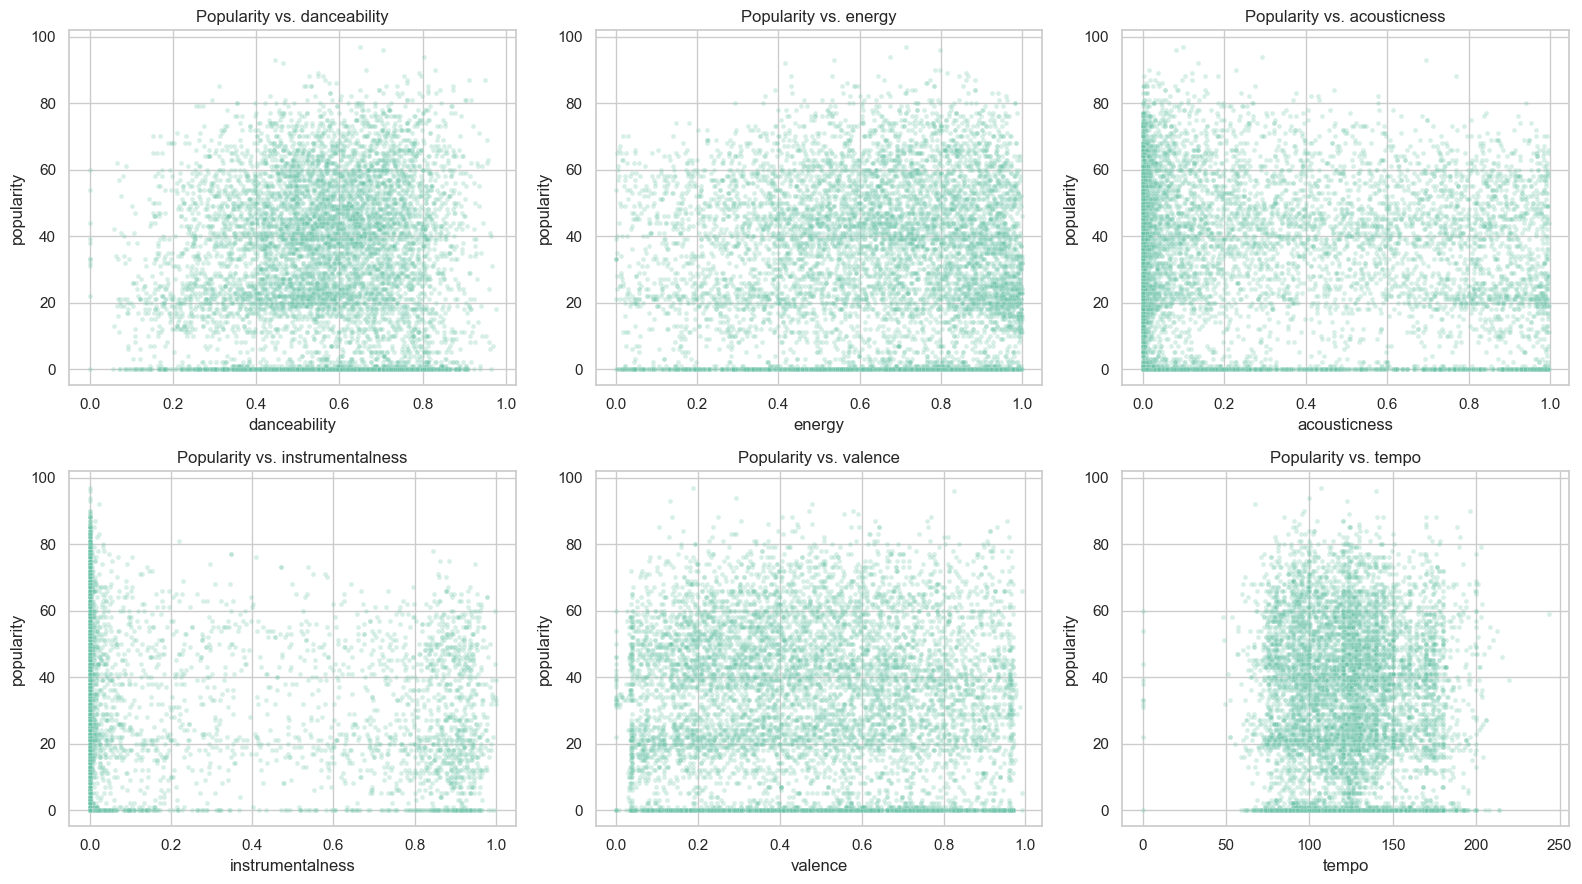

In [10]:
scatter_features = ["danceability", "energy", "acousticness", "instrumentalness", "valence", "tempo"]
sample_df = df.sample(n=min(8000, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, feature in zip(axes.ravel(), scatter_features):
    sns.scatterplot(data=sample_df, x=feature, y="popularity", alpha=0.25, s=12, ax=ax)
    ax.set_title(f"Popularity vs. {feature}")
plt.tight_layout()
plt.show()

## Genre Context

Genre is a business-relevant grouping because Spotify recommendations and editorial playlists often operate by genre or mood. Popularity differences by genre can inform segmentation, but they should not be interpreted as purely audio-driven differences.

,count,mean,median
track_genre,,,
anime,1000,48.772,50.0
brazil,1000,44.670,45.0
ambient,1000,44.191,50.0
british,1000,43.802,52.0
acoustic,1000,42.483,47.0
children,1000,35.047,36.0
cantopop,1000,34.739,35.0
alt-rock,1000,33.943,45.0
blues,1000,31.188,34.0


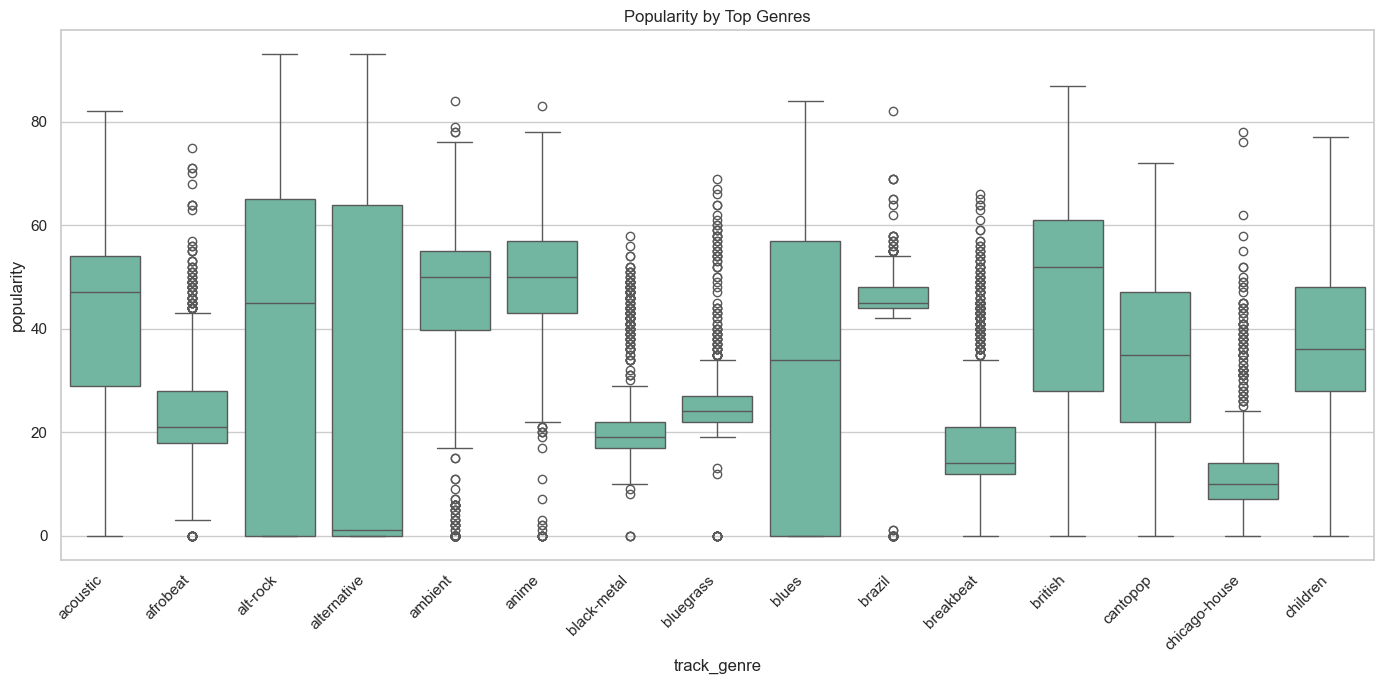

In [11]:
top_genres = df["track_genre"].value_counts().head(15).index
genre_popularity = (
    df[df["track_genre"].isin(top_genres)]
    .groupby("track_genre")["popularity"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
)
display(genre_popularity)

plt.figure(figsize=(14, 7))
sns.boxplot(data=df[df["track_genre"].isin(top_genres)], x="track_genre", y="popularity")
plt.xticks(rotation=45, ha="right")
plt.title("Popularity by Top Genres")
plt.tight_layout()
plt.show()

## EDA Takeaways

The dataset is large enough for reliable train/test splits and includes a rich set of audio features. Popularity is noisy and not explained by audio features alone, so models should be evaluated by generalization performance rather than expecting perfect predictions. Standardization is necessary for PCA, clustering, and neural networks because the variables use different units and scales.